# 02 — Model Training: Forward Surrogate + Tandem Inverse Design

Implements the two-network tandem pipeline from [PixelAnt](https://github.com/udaykdk/pixelant):

```
Phase A — Forward Surrogate (Layout → S-parameters)
  Layout (12×12 = 144) ──► [MLP] ──► S₁₁ at 81 freq points

Phase B — Tandem Inverse Design (freeze Forward, train Inverse)
  S-spec (81) ──► [Inverse MLP + Sigmoid] ──► Layout (144)
                              │
                              ▼ (binarize → pass through frozen Forward)
                           Predicted S₁₁ ◄── Joint loss (performance + binary)
```

Run **01_dataset.ipynb** first to generate `data_split.npz`.

In [1]:
import os, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

NB_DIR    = Path(os.path.abspath(''))
MODEL_DIR = NB_DIR / 'models'
MODEL_DIR.mkdir(exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

GRID_DIM = 12          # 12×12 pixel grid
N_PIXELS = GRID_DIM ** 2   # 144
N_FREQ   = 81          # S11 at 81 frequency points

Device  : cuda
PyTorch : 2.10.0+cu128


In [2]:
# ── Load pre-split dataset ────────────────────────────────────────────────────
split = np.load(NB_DIR / 'data_split.npz')
freqs = split['freqs']     # GHz

def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

X_train = to_tensor(split['X_train'])   # (N, 12, 12)
Y_train = to_tensor(split['Y_train'])   # (N, 81)
X_val   = to_tensor(split['X_val'])
Y_val   = to_tensor(split['Y_val'])
X_test  = to_tensor(split['X_test'])
Y_test  = to_tensor(split['Y_test'])

print(f'Train : X={tuple(X_train.shape)}  Y={tuple(Y_train.shape)}')
print(f'Val   : X={tuple(X_val.shape)}  Y={tuple(Y_val.shape)}')

# ── Per-frequency z-score normalisation with outlier clamping ─────────────────
# Problem without clamping:
#   Y_std varies from 0.315 to 2.43 dB across frequencies.
#   At low-std frequencies a single deep resonance reaches -106σ.
#   MSE then memorises those rare outlier patterns → val loss INCREASES.
# Fix: clamp z-score to ±5σ. Anything beyond 5σ is a near-perfect resonance;
#   the difference between -10σ and -5σ is physically irrelevant to design.
Y_mean = Y_train.mean(0, keepdim=True)              # (1, 81)
Y_std  = Y_train.std(0,  keepdim=True).clamp(1e-6)  # (1, 81)
CLIP_Z = 5.0

def znorm(Y):
    return ((Y - Y_mean) / Y_std).clamp(-CLIP_Z, CLIP_Z)

Y_train_n = znorm(Y_train)
Y_val_n   = znorm(Y_val)
Y_test_n  = znorm(Y_test)

np.savez(NB_DIR / 'y_norm_stats.npz',
         Y_mean=Y_mean.numpy(), Y_std=Y_std.numpy(),
         clip_z=np.float32(CLIP_Z), freqs=freqs)
print(f'\nNorm stats saved → y_norm_stats.npz')
print(f'Y_std  : [{Y_std.min():.3f}, {Y_std.max():.3f}] dB  (clamp z to ±{CLIP_Z})')
print(f'Y_train_n after clamp : [{Y_train_n.min():.2f}, {Y_train_n.max():.2f}]')

BATCH = 512
train_dl = DataLoader(TensorDataset(X_train, Y_train_n), batch_size=BATCH,
                      shuffle=True,  num_workers=4, pin_memory=True)
val_dl   = DataLoader(TensorDataset(X_val,   Y_val_n),   batch_size=BATCH,
                      shuffle=False, num_workers=4, pin_memory=True)
print(f'Batch={BATCH}  train_batches={len(train_dl)}')

Train : X=(541983, 12, 12)  Y=(541983, 81)
Val   : X=(67748, 12, 12)  Y=(67748, 81)

Norm stats saved → y_norm_stats.npz
Y_std  : [0.315, 2.430] dB  (clamp z to ±5.0)
Y_train_n after clamp : [-5.00, 2.71]
Batch=512  train_batches=1059


In [3]:
import torch.nn.functional as F

# ─────────────────────────────────────────────────────────────────────────────
# Shared building blocks
# ─────────────────────────────────────────────────────────────────────────────

class ResBlock1D(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.1):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.ff   = nn.Sequential(
            nn.Linear(dim, dim * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim * 2, dim), nn.Dropout(dropout),
        )
    def forward(self, x): return x + self.ff(self.norm(x))


class SpatialResBlock(nn.Module):
    def __init__(self, ch: int, groups: int = 8):
        super().__init__()
        g = min(groups, ch)
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch), nn.GELU(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch),
        )
    def forward(self, x): return F.gelu(x + self.block(x))


class SEBlock(nn.Module):
    def __init__(self, ch: int, r: int = 8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(ch, max(ch // r, 4)), nn.GELU(),
            nn.Linear(max(ch // r, 4), ch), nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.fc(x).view(-1, x.size(1), 1, 1)


class SpatialResBlockSE(nn.Module):
    def __init__(self, ch: int, groups: int = 8):
        super().__init__()
        g = min(groups, ch)
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch), nn.GELU(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch),
        )
        self.se = SEBlock(ch)
    def forward(self, x):
        return F.gelu(x + self.se(self.block(x)))


# ─────────────────────────────────────────────────────────────────────────────
# Forward Surrogate v4 — larger CoordConv + SE-ResNet + multi-scale
#
# Changes from v3 (cnn_ch=32, hidden=512, n_res=2, dropout=0.25, 4 blocks):
#   cnn_ch=48, n_res=3, dropout=0.10, 6 MLP head blocks
#   ms_dim = 48 + 96 + 192×9 = 1872  (was 1248)
#   → More capacity for sharp resonance depth + frequency accuracy
# ─────────────────────────────────────────────────────────────────────────────

class ForwardSurrogateNet(nn.Module):
    """Layout image (12×12) → normalised S₁₁ at 81 frequency points."""
    def __init__(self, grid_dim=12, n_freq=81, cnn_ch=48, hidden=512, n_res=3):
        super().__init__()
        self.grid_dim = grid_dim
        self.stage1 = nn.Sequential(
            nn.Conv2d(3, cnn_ch, 3, padding=1, bias=False),
            nn.GroupNorm(min(8, cnn_ch), cnn_ch), nn.GELU(),
            *[SpatialResBlockSE(cnn_ch) for _ in range(n_res)],
        )
        self.down1 = nn.Sequential(
            nn.Conv2d(cnn_ch, cnn_ch * 2, 3, stride=2, padding=1, bias=False),
            nn.GroupNorm(min(8, cnn_ch * 2), cnn_ch * 2), nn.GELU(),
        )
        self.stage2 = nn.Sequential(*[SpatialResBlockSE(cnn_ch * 2) for _ in range(n_res)])
        self.down2 = nn.Sequential(
            nn.Conv2d(cnn_ch * 2, cnn_ch * 4, 3, stride=2, padding=1, bias=False),
            nn.GroupNorm(min(8, cnn_ch * 4), cnn_ch * 4), nn.GELU(),
        )
        self.stage3 = nn.Sequential(*[SpatialResBlockSE(cnn_ch * 4) for _ in range(n_res)])
        ms_dim = cnn_ch + cnn_ch * 2 + cnn_ch * 4 * 3 * 3   # 48+96+1728=1872
        self.head = nn.Sequential(
            nn.Linear(ms_dim, hidden), nn.GELU(), nn.Dropout(0.10),
            *[ResBlock1D(hidden, dropout=0.10) for _ in range(6)],
            nn.Linear(hidden, n_freq),
        )

    def _add_coords(self, x):
        B, _, H, W = x.shape
        rows = torch.linspace(-1, 1, H, device=x.device).view(1, 1, H, 1).expand(B, 1, H, W)
        cols = torch.linspace(-1, 1, W, device=x.device).view(1, 1, 1, W).expand(B, 1, H, W)
        return torch.cat([x, rows, cols], dim=1)

    def forward(self, x):
        if x.dim() == 2:   x = x.view(-1, 1, self.grid_dim, self.grid_dim)
        elif x.dim() == 3: x = x.unsqueeze(1)
        x  = self._add_coords(x)
        f1 = self.stage1(x)
        f2 = self.stage2(self.down1(f1))
        f3 = self.stage3(self.down2(f2))
        ms = torch.cat([f1.mean(dim=(-2,-1)), f2.mean(dim=(-2,-1)), f3.flatten(1)], dim=1)
        return self.head(ms)


# ── Legacy classes (kept for compatibility) ───────────────────────────────────
class ConvEncoder(nn.Module):
    def __init__(self, n_freq=81, latent_dim=32, cnn_ch=32, hidden=256):
        super().__init__()
        self.layout_cnn = nn.Sequential(
            nn.Conv2d(1, cnn_ch, 3, padding=1, bias=False),
            nn.GroupNorm(8, cnn_ch), nn.GELU(), SpatialResBlock(cnn_ch),
            nn.Conv2d(cnn_ch, cnn_ch*2, 3, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, cnn_ch*2), nn.GELU(), SpatialResBlock(cnn_ch*2),
            nn.Conv2d(cnn_ch*2, cnn_ch*4, 3, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, cnn_ch*4), nn.GELU(),
        )
        layout_feat = cnn_ch * 4 * 3 * 3
        self.s11_enc = nn.Sequential(nn.Linear(n_freq, hidden), nn.GELU(), ResBlock1D(hidden))
        self.fusion  = nn.Sequential(nn.Linear(layout_feat + hidden, hidden), nn.GELU(), ResBlock1D(hidden))
        self.fc_mu   = nn.Linear(hidden, latent_dim)
        self.fc_lv   = nn.Linear(hidden, latent_dim)
    def forward(self, layout_img, s11):
        h = self.fusion(torch.cat([self.layout_cnn(layout_img).flatten(1),
                                   self.s11_enc(s11)], dim=-1))
        return self.fc_mu(h), self.fc_lv(h)

class ConvDecoder(nn.Module):
    def __init__(self, n_freq=81, latent_dim=32, cnn_ch=32, hidden=256):
        super().__init__()
        seed_ch = cnn_ch * 4
        self.s11_enc   = nn.Sequential(nn.Linear(n_freq, hidden), nn.GELU(), ResBlock1D(hidden))
        self.seed_proj = nn.Sequential(nn.Linear(latent_dim + hidden, seed_ch * 3 * 3), nn.GELU())
        self.deconv = nn.Sequential(
            SpatialResBlock(seed_ch),
            nn.ConvTranspose2d(seed_ch, cnn_ch*2, 4, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, cnn_ch*2), nn.GELU(), SpatialResBlock(cnn_ch*2),
            nn.ConvTranspose2d(cnn_ch*2, cnn_ch, 4, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, cnn_ch), nn.GELU(), SpatialResBlock(cnn_ch),
            nn.Conv2d(cnn_ch, 1, 1), nn.Sigmoid(),
        )
        self.seed_ch = seed_ch
    def forward(self, z, s11):
        seed = self.seed_proj(torch.cat([z, self.s11_enc(s11)], dim=-1)).view(-1, self.seed_ch, 3, 3)
        return self.deconv(seed).squeeze(1)

class cVAEInverseNet(nn.Module):
    def __init__(self, n_freq=81, n_pixels=144, grid_dim=12, latent_dim=32, cnn_ch=32, hidden=256):
        super().__init__()
        self.grid_dim   = grid_dim
        self.latent_dim = latent_dim
        self.encoder = ConvEncoder(n_freq, latent_dim, cnn_ch, hidden)
        self.decoder = ConvDecoder(n_freq, latent_dim, cnn_ch, hidden)
    def sample(self, s11, k=1):
        z = torch.randn(k, self.latent_dim, device=s11.device)
        return self.decoder(z, s11.expand(k, -1))

# ─────────────────────────────────────────────────────────────────────────────
forward_model = ForwardSurrogateNet(GRID_DIM, N_FREQ, cnn_ch=48, hidden=512, n_res=3).to(DEVICE)
inverse_model = cVAEInverseNet(N_FREQ, N_PIXELS, GRID_DIM, latent_dim=32, cnn_ch=32, hidden=256).to(DEVICE)

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f'ForwardSurrogateNet v4 (cnn_ch=48, n_res=3, 6-block head) : {count_params(forward_model):>8,} params')
print(f'cVAEInverseNet (legacy, overridden by b3000008)            : {count_params(inverse_model):>8,} params')


ForwardSurrogateNet v4 (cnn_ch=48, n_res=3, 6-block head) : 10,170,863 params
cVAEInverseNet (legacy, overridden by b3000008)            : 2,279,809 params


In [4]:
# ── Phase A: Train Forward Surrogate v4 ──────────────────────────────────────
# FORCE_RETRAIN_FWD=False (default) → resumes from last epoch automatically
# FORCE_RETRAIN_FWD=True            → wipes all checkpoints and starts fresh

FORCE_RETRAIN_FWD = False   # ← set True only to start over from scratch


def shape_aware_loss(pred, target):
    """Resonance-aware loss: depth-weighted MSE + depth-weighted gradient + curvature."""
    res_w    = 1.0 + 3.0 * F.relu(-target) / CLIP_Z
    res_loss = (res_w * (pred - target).pow(2)).mean()
    dp, dt   = pred[:, 1:] - pred[:, :-1], target[:, 1:] - target[:, :-1]
    grad_loss = (res_w[:, 1:] * (dp - dt).pow(2)).mean()
    d2p = pred[:, 2:] - 2 * pred[:, 1:-1] + pred[:, :-2]
    d2t = target[:, 2:] - 2 * target[:, 1:-1] + target[:, :-2]
    return res_loss + 2.0 * grad_loss + F.mse_loss(d2p, d2t)


def eval_loss_batched(model, X, Y_n, batch_size=512):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = X[i:i+batch_size].to(DEVICE)
            yb = Y_n[i:i+batch_size].to(DEVICE)
            total += F.mse_loss(model(xb), yb).item() * len(xb)
            n += len(xb)
    return total / n


FWD_EPOCHS = 200
FWD_LR     = 2e-4

_fwd_ckpt        = MODEL_DIR / 'forward_model.pt'         # best weights only
_fwd_resume_ckpt = MODEL_DIR / 'forward_model_resume.pt'  # full state for resuming

optimizer_f = torch.optim.AdamW(forward_model.parameters(), lr=FWD_LR, weight_decay=1e-3)
scheduler_f = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_f, mode='min', factor=0.5, patience=15, min_lr=1e-6)

fwd_train_loss, fwd_val_loss = [], []
best_val, best_state = float('inf'), None
start_epoch = 1

if not FORCE_RETRAIN_FWD:
    if _fwd_resume_ckpt.exists():
        ckpt = torch.load(_fwd_resume_ckpt, map_location=DEVICE)
        forward_model.load_state_dict(ckpt['model_state'])
        optimizer_f.load_state_dict(ckpt['optimizer_state'])
        scheduler_f.load_state_dict(ckpt['scheduler_state'])
        best_val       = ckpt['best_val']
        best_state     = ckpt['best_model_state']
        fwd_train_loss = ckpt['train_loss']
        fwd_val_loss   = ckpt['val_loss']
        start_epoch    = ckpt['epoch'] + 1
        print(f'Resumed from epoch {ckpt["epoch"]}/{FWD_EPOCHS}  best_val={best_val:.5f}')
    elif _fwd_ckpt.exists():
        try:
            forward_model.load_state_dict(torch.load(_fwd_ckpt, map_location=DEVICE))
            forward_model.eval()
            val_mse = eval_loss_batched(forward_model, X_val, Y_val_n)
            print(f'Loaded forward_model.pt (val MSE={val_mse:.5f}) — skipping training.')
            start_epoch = FWD_EPOCHS + 1
        except Exception as e:
            print(f'Checkpoint incompatible ({e.__class__.__name__}). Retraining from scratch.')

if start_epoch <= FWD_EPOCHS:
    print(f'Training ForwardSurrogateNet v4  epochs {start_epoch}→{FWD_EPOCHS}')
    print(f'  loss: depth-weighted MSE + 2×depth-grad + curvature')
    t0 = time.time()

    for epoch in range(start_epoch, FWD_EPOCHS + 1):
        forward_model.train()
        ep_loss = 0.0
        for layouts, em_specs_n in train_dl:
            em_specs_n = em_specs_n.to(DEVICE)
            layouts    = layouts.to(DEVICE)
            optimizer_f.zero_grad()
            loss = shape_aware_loss(forward_model(layouts), em_specs_n)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(forward_model.parameters(), 1.0)
            optimizer_f.step()
            ep_loss += loss.item() * len(layouts)
        ep_loss /= len(X_train)

        v_loss = eval_loss_batched(forward_model, X_val, Y_val_n)
        scheduler_f.step(v_loss)
        fwd_train_loss.append(ep_loss)
        fwd_val_loss.append(v_loss)

        if v_loss < best_val:
            best_val   = v_loss
            best_state = {k: v.cpu().clone() for k, v in forward_model.state_dict().items()}
            torch.save(best_state, _fwd_ckpt)          # ModelCheckpoint: save when val improves

        # Overwrite every epoch — enables resume after any crash/interrupt
        torch.save({
            'epoch':            epoch,
            'model_state':      forward_model.state_dict(),
            'optimizer_state':  optimizer_f.state_dict(),
            'scheduler_state':  scheduler_f.state_dict(),
            'best_val':         best_val,
            'best_model_state': best_state,
            'train_loss':       fwd_train_loss,
            'val_loss':         fwd_val_loss,
        }, _fwd_resume_ckpt)

        if epoch % 10 == 0 or epoch == start_epoch:
            lr_now = optimizer_f.param_groups[0]['lr']
            print(f'  Epoch {epoch:3d}/{FWD_EPOCHS}  train={ep_loss:.5f}  val={v_loss:.5f}  '
                  f'best={best_val:.5f}  lr={lr_now:.2e}')

    forward_model.load_state_dict(best_state)
    print(f'\nDone in {time.time()-t0:.1f}s | Best val MSE: {best_val:.5f}')
    print(f'Best weights → {_fwd_ckpt}')


Resumed from epoch 200/200  best_val=0.09324


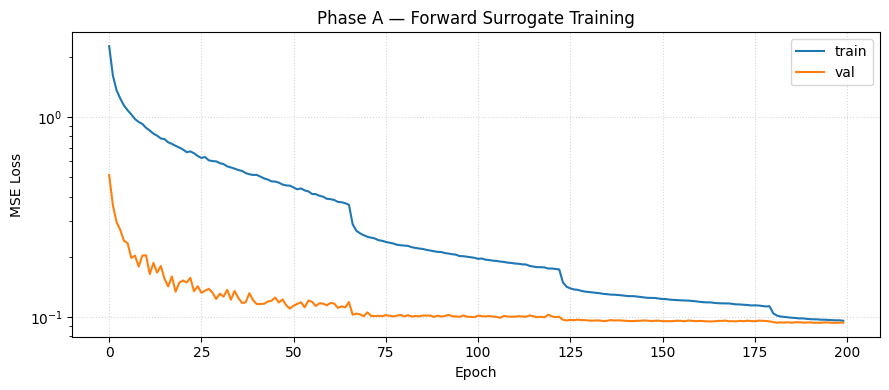

In [5]:
# ── Phase A: loss curves ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(fwd_train_loss, label='train')
ax.semilogy(fwd_val_loss,   label='val')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Phase A — Forward Surrogate Training')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(NB_DIR / 'fig_fwd_loss.png', dpi=120, bbox_inches='tight')
plt.show()

Test MSE (normalised) : 0.09136  ← target < 0.5 for good fit
Test MSE (dB²)        : 0.63619
Test RMSE (dB)        : 0.7976


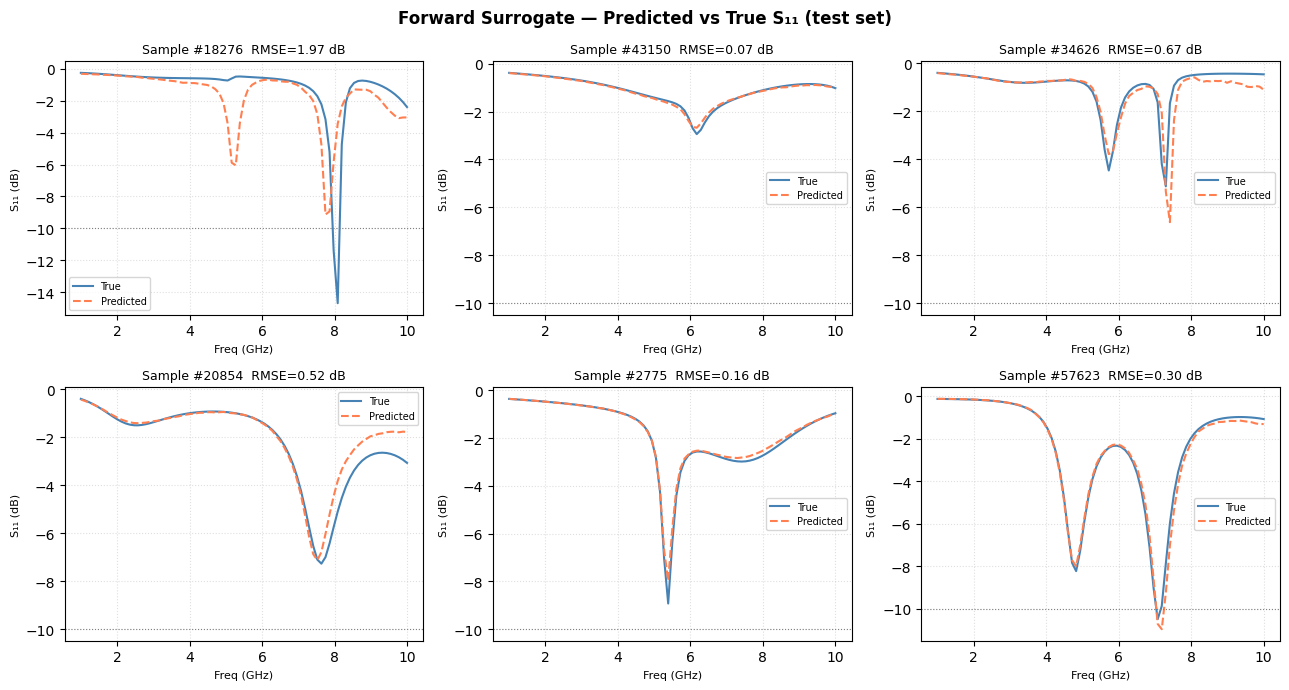

In [6]:
# ── Phase A: qualitative evaluation on test set ───────────────────────────────
# Evaluate in batches (avoid OOM), then unnormalise predictions for display
forward_model.eval()
pred_s11_n_parts = []
with torch.no_grad():
    for i in range(0, len(X_test), 512):
        xb = X_test[i:i+512].to(DEVICE)
        pred_s11_n_parts.append(forward_model(xb).cpu())

pred_s11_n = torch.cat(pred_s11_n_parts, dim=0)                 # (N, 81) z-scored
pred_s11   = (pred_s11_n * Y_std + Y_mean).numpy()              # (N, 81) dB
true_s11   = Y_test.numpy()

test_mse_n = F.mse_loss(pred_s11_n, Y_test_n).item()
test_mse   = float(((pred_s11 - true_s11) ** 2).mean())
print(f'Test MSE (normalised) : {test_mse_n:.5f}  ← target < 0.5 for good fit')
print(f'Test MSE (dB²)        : {test_mse:.5f}')
print(f'Test RMSE (dB)        : {test_mse**0.5:.4f}')

rng = np.random.default_rng(0)
idx = rng.choice(len(X_test), size=6, replace=False)
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
fig.suptitle('Forward Surrogate — Predicted vs True S₁₁ (test set)', fontsize=12, fontweight='bold')

for ax, i in zip(axes.flat, idx):
    ax.plot(freqs, true_s11[i],  label='True',      color='steelblue')
    ax.plot(freqs, pred_s11[i],  label='Predicted',  color='coral', linestyle='--')
    ax.axhline(-10, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlabel('Freq (GHz)', fontsize=8)
    ax.set_ylabel('S₁₁ (dB)',   fontsize=8)
    rmse_i = float(((pred_s11[i] - true_s11[i])**2).mean()**0.5)
    ax.set_title(f'Sample #{i}  RMSE={rmse_i:.2f} dB', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(NB_DIR / 'fig_fwd_eval.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# ── InverseNet: Multi-Choice Learning (MCL) — K=8 parallel heads ──────────────
#
# Why MCL beats VAE/cVAE/product-gate here:
#   • Inverse problem is 1-to-many: many layouts → same S11.
#   • With z + BCE, BCE forces every z to produce the *same* GT layout, so z
#     becomes effectively ignored and best-of-8 ≈ best-of-1.
#   • MCL: K=8 parallel decoder heads. Loss = best-of-K tandem. Each head
#     specialises on a different mode of the layout distribution.
#   • Training objective (best-of-K) exactly matches val_best8 — no mismatch.
#   • No latent z, no posterior collapse, no KL tuning.
#
# Save policy: inverse_model.pt written on every val_best8 improvement AND
# unconditionally at end of training. _resume.pt written every epoch.
# Set FORCE_RETRAIN_INV=True only to wipe and start over.

import shutil, math

SRC_MODEL_DIR = NB_DIR.parent.parent / 'src' / 'gelochip' / 'pixelrf' / 'models'
SRC_MODEL_DIR.mkdir(parents=True, exist_ok=True)
for _src, _dst in [
    (NB_DIR / 'y_norm_stats.npz',   SRC_MODEL_DIR.parent / 'y_norm_stats.npz'),
    (MODEL_DIR / 'forward_model.pt', SRC_MODEL_DIR / 'forward_model.pt'),
]:
    if _src.exists(): shutil.copy2(_src, _dst)

torch.cuda.empty_cache()
FORCE_RETRAIN_INV = False   # ← False = auto-resume from _resume.pt; True = wipe & restart
_inv_ckpt   = SRC_MODEL_DIR / 'inverse_model.pt'
_inv_resume = SRC_MODEL_DIR / '_resume.pt'

N_HEADS    = 8
GEN_EPOCHS = 200
BATCH_INV  = 512
PEAK_LR    = 3e-4
WARMUP_EP  = 5
W_BEST     = 1.0    # best-of-K tandem  (== val metric)
W_MEAN     = 0.1    # mean-K tandem     (keeps all heads training)
W_ANCHOR   = 0.02   # BCE on best head vs GT  (soft on-manifold anchor)


# ── Architecture ──────────────────────────────────────────────────────────────

class ResMLP(nn.Module):
    def __init__(self, dim: int, mult: int = 2, drop: float = 0.1):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.ff   = nn.Sequential(
            nn.Linear(dim, dim * mult), nn.GELU(), nn.Dropout(drop),
            nn.Linear(dim * mult, dim), nn.Dropout(drop),
        )
    def forward(self, x): return x + self.ff(self.norm(x))


class InverseNet(nn.Module):
    """Multi-Choice Learning: K parallel decoders compete via best-of-K loss."""
    def __init__(self, n_freq=81, grid_dim=12, n_heads=8, base_ch=64, hidden=512):
        super().__init__()
        self.grid_dim = grid_dim
        self.n_heads  = n_heads
        c = base_ch
        s11_dim = c * 4   # 256

        self.s11_enc = nn.Sequential(
            nn.Conv1d(1,   c,   7, padding=3,           bias=False), nn.GroupNorm(8, c),   nn.GELU(),
            nn.Conv1d(c,   c*2, 5, padding=2, stride=2, bias=False), nn.GroupNorm(8, c*2), nn.GELU(),
            nn.Conv1d(c*2, c*2, 3, padding=1,           bias=False), nn.GroupNorm(8, c*2), nn.GELU(),
            nn.Conv1d(c*2, c*4, 5, padding=2, stride=2, bias=False), nn.GroupNorm(8, c*4), nn.GELU(),
            nn.Conv1d(c*4, c*4, 3, padding=1,           bias=False), nn.GroupNorm(8, c*4), nn.GELU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
        )
        self.trunk = nn.Sequential(
            nn.Linear(s11_dim, hidden), nn.LayerNorm(hidden), nn.GELU(),
            ResMLP(hidden), ResMLP(hidden), ResMLP(hidden),
        )
        self.heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.GELU(),
                ResMLP(hidden),
                nn.Linear(hidden, grid_dim * grid_dim),
            ) for _ in range(n_heads)
        ])
        for i, h in enumerate(self.heads):
            for layer in h.modules():
                if isinstance(layer, nn.Linear) and layer.bias is not None:
                    nn.init.uniform_(layer.bias, -0.02 * (i + 1) / n_heads,
                                                  0.02 * (i + 1) / n_heads)

    def _all_logits(self, s11):
        s_h = self.s11_enc(s11.unsqueeze(1))
        t   = self.trunk(s_h)
        logits = torch.stack([h(t) for h in self.heads], dim=1)
        return logits.view(-1, self.n_heads, self.grid_dim, self.grid_dim)

    def decode(self, z, s11, tau=None):
        logits = self._all_logits(s11)
        return torch.sigmoid(logits[:, 0]), logits[:, 0]

    def sample(self, s11, k=None):
        with torch.no_grad():
            logits = self._all_logits(s11)
            if logits.shape[0] == 1:
                return (logits[0] > 0).float()
            return (logits > 0).float()


inv_model = InverseNet(n_freq=N_FREQ, grid_dim=GRID_DIM,
                       n_heads=N_HEADS, base_ch=64, hidden=512).to(DEVICE)
for p in forward_model.parameters():
    p.requires_grad_(False)
forward_model.eval()
n_params = sum(p.numel() for p in inv_model.parameters())
print(f'InverseNet (MCL, K={N_HEADS}): {n_params:,} params')
print(f'  batch={BATCH_INV}, fwd-model lower bound ≈ 0.093')
print(f'  ckpt   → {_inv_ckpt}')
print(f'  resume → {_inv_resume}')


# ── Eval ──────────────────────────────────────────────────────────────────────

@torch.no_grad()
def eval_best_of_K(model, fwd, Y_n, batch_size=256):
    model.eval()
    total, n = 0.0, 0
    for i in range(0, len(Y_n), batch_size):
        yb = Y_n[i:i+batch_size].to(DEVICE)
        logits = model._all_logits(yb)
        bins   = (logits > 0).float()
        B, K   = bins.shape[:2]
        flat   = bins.view(B*K, GRID_DIM*GRID_DIM)
        pred   = fwd(flat).view(B, K, N_FREQ)
        mse    = ((pred - yb.unsqueeze(1))**2).mean(-1)
        total += mse.min(1)[0].sum().item()
        n     += B
    return total / n


# ── Optimiser + schedule ──────────────────────────────────────────────────────

train_dl_inv = DataLoader(TensorDataset(X_train, Y_train_n), batch_size=BATCH_INV,
                          shuffle=True, num_workers=4, pin_memory=True, drop_last=True)

optimizer = torch.optim.AdamW(inv_model.parameters(), lr=PEAK_LR,
                              betas=(0.9, 0.95), weight_decay=1e-4)

total_steps  = GEN_EPOCHS * len(train_dl_inv)
warmup_steps = WARMUP_EP  * len(train_dl_inv)

def lr_at(step):
    if step < warmup_steps:
        return PEAK_LR * (step + 1) / max(1, warmup_steps)
    p = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return PEAK_LR * (0.05 + 0.95 * 0.5 * (1 + math.cos(math.pi * p)))


# ── Resume (robust to architecture mismatch) ──────────────────────────────────

train_loss_hist, val_perf_hist = [], []
best_val, best_state = float('inf'), None
start_epoch = 1
global_step = 0

if not FORCE_RETRAIN_INV and _inv_resume.exists():
    try:
        ckpt = torch.load(_inv_resume, map_location=DEVICE)
        inv_model.load_state_dict(ckpt['model_state'])     # raises if arch changed
        optimizer.load_state_dict(ckpt['optimizer_state'])
        best_val        = ckpt['best_val']
        best_state      = ckpt['best_model_state']
        train_loss_hist = ckpt['train_loss']
        val_perf_hist   = ckpt['val_perf']
        start_epoch     = ckpt['epoch'] + 1
        global_step     = ckpt.get('global_step', (start_epoch - 1) * len(train_dl_inv))
        print(f'Resumed from epoch {ckpt["epoch"]}/{GEN_EPOCHS}  best_val={best_val:.5f}  step={global_step}')
    except (RuntimeError, KeyError) as e:
        print(f'⚠ Resume failed ({e.__class__.__name__}: stale architecture in _resume.pt). Starting fresh.')
        start_epoch = 1; global_step = 0; best_val = float('inf'); best_state = None
        train_loss_hist, val_perf_hist = [], []
elif FORCE_RETRAIN_INV:
    print('FORCE_RETRAIN_INV=True — starting from scratch.')


# ── Training ──────────────────────────────────────────────────────────────────

if start_epoch <= GEN_EPOCHS:
    print(f'\nTraining InverseNet (MCL)  epochs {start_epoch}→{GEN_EPOCHS}  batch={BATCH_INV}')
    print(f'  loss = {W_BEST}·best-K + {W_MEAN}·mean-K + {W_ANCHOR}·BCE(best,GT)')
    print(f'  {"Epoch":>5}  {"best":>8}  {"mean":>8}  {"anchor":>8}  {"val_best8":>9}  {"lr":>9}')
    t0 = time.time()

    for epoch in range(start_epoch, GEN_EPOCHS + 1):
        inv_model.train()
        ep_best = ep_mean = ep_anc = 0.0
        n_samp = 0

        for layouts, s11_b in train_dl_inv:
            layouts = layouts.to(DEVICE).float()
            s11_b   = s11_b.to(DEVICE).float()
            B       = len(s11_b)

            logits = inv_model._all_logits(s11_b)
            K      = logits.shape[1]

            probs = torch.sigmoid(logits)
            ste   = probs + ((logits > 0).float() - probs).detach()
            flat  = ste.view(B*K, GRID_DIM*GRID_DIM)
            pred  = forward_model(flat).view(B, K, N_FREQ)
            mse_k = ((pred - s11_b.unsqueeze(1))**2).mean(-1)

            best_idx  = mse_k.argmin(1)
            best_loss = mse_k.gather(1, best_idx.unsqueeze(1)).mean()
            mean_loss = mse_k.mean()

            best_logits = logits[torch.arange(B, device=DEVICE), best_idx]
            bce_anchor  = F.binary_cross_entropy_with_logits(best_logits, layouts)

            loss = W_BEST * best_loss + W_MEAN * mean_loss + W_ANCHOR * bce_anchor

            for pg in optimizer.param_groups: pg['lr'] = lr_at(global_step)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(inv_model.parameters(), 1.0)
            optimizer.step()
            global_step += 1

            ep_best += best_loss.item() * B
            ep_mean += mean_loss.item() * B
            ep_anc  += bce_anchor.item() * B
            n_samp  += B

        ep_best /= n_samp; ep_mean /= n_samp; ep_anc /= n_samp
        v_perf = eval_best_of_K(inv_model, forward_model, Y_val_n)
        train_loss_hist.append(ep_best); val_perf_hist.append(v_perf)

        cur_lr = optimizer.param_groups[0]['lr']
        marker = ''
        if v_perf < best_val:
            best_val   = v_perf
            best_state = {k: v.cpu().clone() for k, v in inv_model.state_dict().items()}
            torch.save(best_state, _inv_ckpt)
            marker = ' ←best (saved)'

        torch.save({'epoch': epoch, 'model_state': inv_model.state_dict(),
                    'optimizer_state': optimizer.state_dict(), 'best_val': best_val,
                    'best_model_state': best_state, 'train_loss': train_loss_hist,
                    'val_perf': val_perf_hist, 'global_step': global_step}, _inv_resume)

        if epoch % 5 == 0 or epoch <= 10:
            print(f'  {epoch:5d}  {ep_best:8.4f}  {ep_mean:8.4f}  {ep_anc:8.4f}  '
                  f'{v_perf:9.4f}  {cur_lr:9.2e}{marker}')

    if best_state is not None:
        inv_model.load_state_dict(best_state)
    torch.save(inv_model.state_dict(), _inv_ckpt)
    print(f'\nDone in {time.time()-t0:.1f}s  |  Best val_best8: {best_val:.5f}')
    print(f'✓ Saved  → {_inv_ckpt}')
    print(f'✓ Resume → {_inv_resume}')
else:
    state = torch.load(_inv_ckpt, map_location=DEVICE)
    inv_model.load_state_dict(state)
    print(f'[skip] All {GEN_EPOCHS} epochs done. Loaded {_inv_ckpt}')


InverseNet (MCL, K=8): 14,848,192 params
  batch=512, fwd-model lower bound ≈ 0.093
  ckpt   → /home/irman/Gelochip/src/gelochip/pixelrf/models/inverse_model.pt
  resume → /home/irman/Gelochip/src/gelochip/pixelrf/models/_resume.pt
Resumed from epoch 28/200  best_val=0.12752  step=29624

Training InverseNet (MCL)  epochs 29→200  batch=512
  loss = 1.0·best-K + 0.1·mean-K + 0.02·BCE(best,GT)
  Epoch      best      mean    anchor  val_best8         lr
     30    0.1323    0.3940    0.9236     0.1278   2.89e-04
     35    0.1303    0.3959    0.9236     0.1261   2.84e-04
     40    0.1286    0.3925    0.9243     0.1210   2.78e-04 ←best (saved)
     45    0.1269    0.3895    0.9258     0.1204   2.71e-04
     50    0.1261    0.3897    0.9278     0.1210   2.64e-04
     55    0.1249    0.3861    0.9287     0.1185   2.56e-04
     60    0.1245    0.3879    0.9279     0.1175   2.48e-04
     65    0.1244    0.3884    0.9282     0.1177   2.38e-04
     70    0.1227    0.3874    0.9285     0.1136   2

KeyboardInterrupt: 

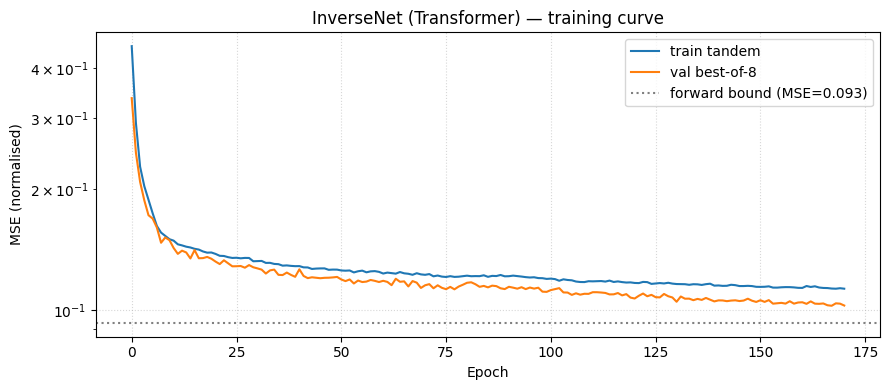

Best val best-of-8: 0.10257  (forward bound: 0.09324)

Test RMSE (dB) over 1000 samples, best-of-8:
  mean = 0.621   median = 0.495   p90 = 1.215


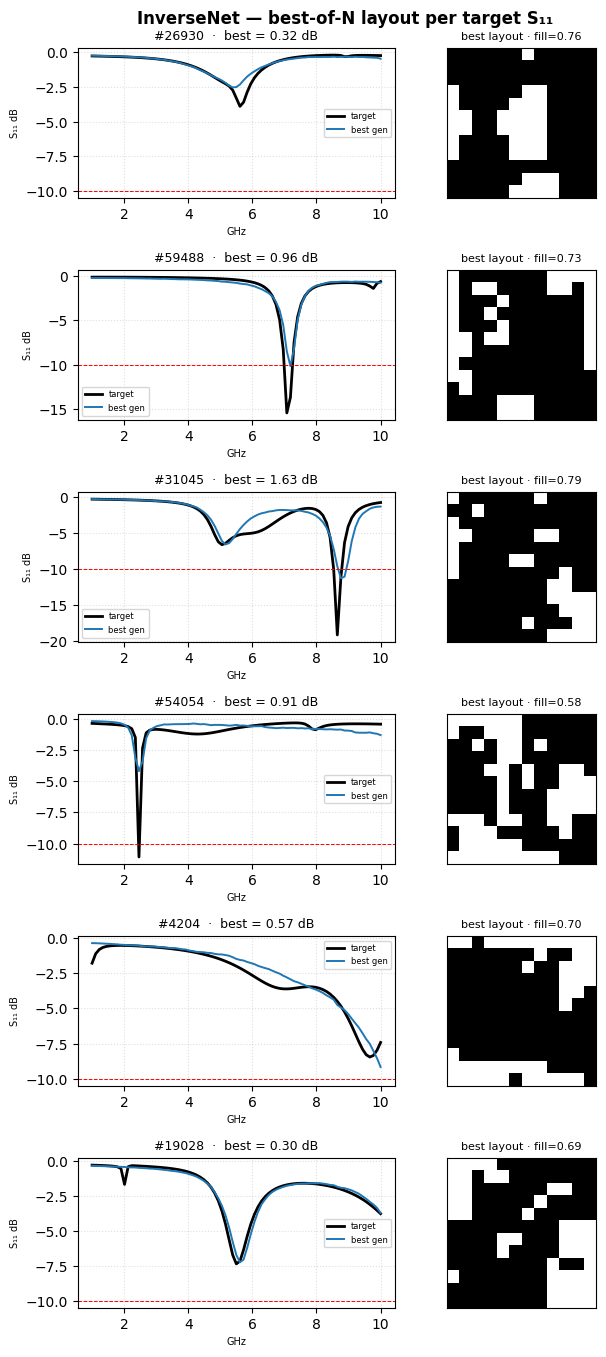

In [10]:
# ── Test evaluation ───────────────────────────────────────────────────────────
# 1. val best-of-N loss curve   2. best-of-N test RMSE   3. per target: the BEST layout
import matplotlib.pyplot as plt

K = inv_model.n_heads          # MCL heads = candidate layouts per target
inv_model.eval(); forward_model.eval()

# ── 1. Training loss curve ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(train_loss_hist, label='train tandem')
ax.semilogy(val_perf_hist,   label=f'val best-of-{K}')
ax.axhline(0.093, color='gray', linestyle=':', label='forward bound (MSE=0.093)')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (normalised)')
ax.set_title('InverseNet (Transformer) — training curve')
ax.legend(); ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout(); plt.savefig(NB_DIR / 'fig_inv_transformer_loss.png', dpi=120); plt.show()
print(f'Best val best-of-{K}: {min(val_perf_hist):.5f}  (forward bound: 0.09324)')

# ── 2. Test RMSE (dB, unnormalised), best-of-N per target ────────────────────
N_TEST_EVAL = 1000
rng = np.random.default_rng(42)
test_idx = rng.choice(len(X_test), size=N_TEST_EVAL, replace=False)

best_rmse = []
with torch.no_grad():
    for i in range(0, N_TEST_EVAL, 64):
        idx_b = test_idx[i:i+64]
        yb_n  = Y_test_n[idx_b].to(DEVICE)
        yb    = Y_test[idx_b].numpy()
        B     = len(idx_b)
        logits = inv_model._all_logits(yb_n)                  # (B, K, grid, grid)
        gen_b  = (logits > 0).float().reshape(B * K, *logits.shape[2:])
        pred_n = forward_model(gen_b).view(B, K, -1).cpu()
        pred_db = (pred_n * Y_std.unsqueeze(0) + Y_mean.unsqueeze(0)).numpy()
        for j in range(B):
            best_rmse.append(np.sqrt(((pred_db[j] - yb[j:j+1])**2).mean(-1)).min())

best_rmse = np.array(best_rmse)
print(f'\nTest RMSE (dB) over {N_TEST_EVAL} samples, best-of-{K}:')
print(f'  mean = {best_rmse.mean():.3f}   median = {np.median(best_rmse):.3f}   '
      f'p90 = {np.percentile(best_rmse, 90):.3f}')

# ── 3. Qualitative: target S₁₁ + the single BEST (min-RMSE) layout ───────────
N_SHOW = 6
vis_idx = rng.choice(len(X_test), size=N_SHOW, replace=False)

fig, axes = plt.subplots(N_SHOW, 2, figsize=(7, 2.3 * N_SHOW))
fig.suptitle('InverseNet — best-of-N layout per target S₁₁', fontsize=12, fontweight='bold')
with torch.no_grad():
    for row, ti in enumerate(vis_idx):
        t_s11_n = Y_test_n[ti].unsqueeze(0).to(DEVICE)
        t_s11   = Y_test[ti].numpy()
        gen     = (inv_model._all_logits(t_s11_n)[0] > 0).float()    # (K, grid, grid)
        pred_db = (forward_model(gen).cpu() * Y_std + Y_mean).numpy()
        rmse_k  = np.sqrt(((pred_db - t_s11[None])**2).mean(-1))
        b       = int(rmse_k.argmin())                               # keep only the best head

        axL = axes[row, 0]
        axL.plot(freqs, t_s11,      'k', lw=2,   label='target')
        axL.plot(freqs, pred_db[b], color='tab:blue', lw=1.4, label='best gen')
        axL.axhline(-10, color='red', ls='--', lw=0.7)
        axL.set_title(f'#{ti}  ·  best = {rmse_k[b]:.2f} dB', fontsize=9)
        axL.set_xlabel('GHz', fontsize=7); axL.set_ylabel('S₁₁ dB', fontsize=7)
        axL.legend(fontsize=6); axL.grid(True, ls=':', alpha=0.4)

        axR = axes[row, 1]
        g = gen[b].cpu().numpy()
        axR.imshow(g, cmap='binary', vmin=0, vmax=1, interpolation='nearest')
        axR.set_title(f'best layout · fill={g.mean():.2f}', fontsize=8)
        axR.set_xticks([]); axR.set_yticks([])

plt.tight_layout(); plt.savefig(NB_DIR / 'fig_inv_best_layout.png', dpi=130); plt.show()